In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [32]:
MAX_LEN = 512
EPOCHS = 20
BATCH_SIZE = 128

# Работа с текстом

In [2]:
df = pd.read_json("hf://datasets/blinoff/kinopoisk/kinopoisk.jsonl", lines=True)
df

,part,movie_name,review_id,author,date,title,grade3,grade10,content
0,top250,Блеф (1976),17144,Come Back,2011-09-24,Плакали наши денежки ©,Good,10.0,"\n""Блеф» — одна из моих самых любимых комедий...."
1,top250,Блеф (1976),17139,Stasiki,2008-03-04,NaN,Good,0.0,\nАдриано Челентано продолжает радовать нас св...
2,top250,Блеф (1976),17137,Flashman,2007-03-04,NaN,Good,10.0,"\nНесомненно, это один из великих фильмов 80-х..."
3,top250,Блеф (1976),17135,Sergio Tishin,2009-08-17,""" Черное, красное, ерунда это все. Выигрывает ...",Good,0.0,\nЭта фраза на мой взгляд отражает сюжет несом...
4,top250,Блеф (1976),17151,Фюльгья,2009-08-20,"«Он хотел убежать? Да! Блеф, блеф…»",Neutral,7.0,"\n- как пела Земфира, скорее всего, по соверше..."
...,...,...,...,...,...,...,...,...,...
36586,bottom100,Цветок дьявола (2010),25123,bestiya163,2010-09-23,"Ой, ой, ой!",Bad,2.0,\n Ну с чего бы начать… Давненько я не пи...
36587,bottom100,Цветок дьявола (2010),25192,Молка,2010-10-02,Молчаливый мужик на коне…,Bad,1.0,"\n Можно начать с того, что уже постер к ..."
36588,bottom100,Цветок дьявола (2010),25080,jetry,2010-09-16,Это проявилось сегодня ночью.,Good,7.0,"\n Фильм производства России, поэтому мно..."
36589,bottom100,Цветок дьявола (2010),25088,Alkort,2010-09-16,«Finita la comedia»,Bad,0.0,\n 16 сентября на большие экраны вышел «м...


In [3]:
df.shape

(36591, 9)

In [4]:
df_model = df[['content', 'grade10']]
df_model['grade10'].value_counts()

grade10
0.000000e+00    13330
1.000000e+01    13236
9.000000e+00     2945
8.000000e+00     1782
7.000000e+00     1023
                ...  
1.800000e+00        1
2.700000e+00        1
1.000000e-09        1
1.000000e-05        1
1.000000e-06        1
Name: count, Length: 69, dtype: int64

In [5]:
df_model = df_model[(df_model['grade10'] <= 10) & (df_model['grade10'] >= 0)]

print(df_model.shape)

df_model['grade10'].value_counts()

(36490, 2)


grade10
0.000000e+00    13330
1.000000e+01    13236
9.000000e+00     2945
8.000000e+00     1782
7.000000e+00     1023
1.000000e+00      865
6.000000e+00      691
5.000000e+00      635
2.000000e+00      537
3.000000e+00      514
4.000000e+00      487
9.500000e+00      129
8.500000e+00      120
7.500000e+00       48
6.500000e+00       32
4.500000e+00       13
5.500000e+00       12
9.900000e+00       10
2.500000e+00        8
1.500000e+00        7
3.500000e+00        6
5.000000e-01        6
9.700000e+00        4
7.700000e+00        4
7.900000e+00        3
8.900000e+00        3
9.990000e+00        2
8.200000e+00        2
9.100000e+00        2
8.300000e+00        2
6.200000e+00        2
8.600000e+00        2
7.400000e+00        2
7.800000e+00        2
1.000000e-02        2
6.300000e+00        1
7.100000e+00        1
7.200000e+00        1
6.800000e+00        1
7.300000e+00        1
9.800000e+00        1
9.400000e+00        1
9.796000e+00        1
7.890000e+00        1
6.600000e+00        1
8.

In [8]:
df_model['grade10'] = df_model['grade10'].round(0)

df_model['grade10'].value_counts().sort_index()

grade10
0.0     13342
1.0       865
2.0       553
3.0       516
4.0       506
5.0       636
6.0       739
7.0      1031
8.0      1965
9.0      2954
10.0    13383
Name: count, dtype: int64

In [10]:
# Находим минимальное количество наблюдений среди всех классов
min_count = df_model['grade10'].value_counts().min()

# Создаем сбалансированный датафрейм
df_balanced = df_model.groupby('grade10').apply(lambda x: x.sample(min_count)).reset_index()

# Проверяем результат
df_balanced['grade10'].value_counts()

grade10
0.0     506
1.0     506
2.0     506
3.0     506
4.0     506
5.0     506
6.0     506
7.0     506
8.0     506
9.0     506
10.0    506
Name: count, dtype: int64

In [11]:
df_model = df_balanced.copy()
df_model

,grade10,level_1,content
0,0.0,5349,"\nКино. Хорошее. Посыл таков, что накрывает вс..."
1,0.0,11115,"\nСчитается, что образованный и духовно развит..."
2,0.0,7655,"\nНе могу сказать, что являюсь поклонником инд..."
3,0.0,15763,\nС большим удовольствием посмотрела несколько...
4,0.0,6702,\nКогда я начинала смотреть фильм «12 разгнева...
...,...,...,...
5561,10.0,20726,"\nВ Голливуде не разучились снимать фильмы, но..."
5562,10.0,27578,"\nЯ уже писал ранее, что Терминатор-это эталон..."
5563,10.0,29949,"\nФильм самый великолепный, какой я только смо..."
5564,10.0,30320,"\nВысшая школа разведки, Восточная Германия: к..."


# Preprocessing

In [18]:
from transformers import AutoTokenizer
TOKENIZER_NAME = "cointegrated/rubert-tiny2"

# Загружаем самый легкий и быстрый токенизатор для русскоязычных текстов.
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

In [20]:
def tokenize_texts(texts: pd.Series, tokenizer: AutoTokenizer, max_len: int):
    """
    Токенизирует серию текстов и возвращает numpy-массивы.

    Параметры:
    texts : pd.Series
        Тексты, которые нужно перевести в token id.
    tokenizer : AutoTokenizer
        Токенизатор Hugging Face.
    max_len : int
        Фиксированная длина последовательности. Все тексты будут обрезаны или дополнены до нее.

    Возвращает:
    Dict[str, np.ndarray]
        Словарь с ключами input_ids и attention_mask.
    """
    return tokenizer(texts.tolist(), max_length=max_len, padding="max_length", truncation=True, return_tensors="np", add_special_tokens=True)

encodings = tokenize_texts(df_model["content"], tokenizer, MAX_LEN)

print("encodings:", encodings["input_ids"].shape)

encodings: (5566, 512)


In [22]:
from sklearn.model_selection import train_test_split

# Разделение данных на тренировочную, валидационную и тестовую выборки
X_train, X_temp, y_train, y_temp = train_test_split(encodings["input_ids"], df_model["grade10"], test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape,

((3896, 512), (835, 512), (835, 512), (3896,), (835,), (835,))

In [23]:
X_train

array([[    2,   575,  2262, ...,     0,     0,     0],
       [    2,  3760, 24644, ...,     0,     0,     0],
       [    2, 17173, 46247, ...,  9103,  9441,     3],
       ...,
       [    2, 33249, 19389, ...,     0,     0,     0],
       [    2, 18013,   811, ..., 50706, 34018,     3],
       [    2, 17641,   320, ...,     0,     0,     0]], shape=(3896, 512))

In [24]:
y_train

4915     9.0
4322     8.0
2271     4.0
1424     2.0
1216     2.0
        ... 
3772     7.0
5191    10.0
5226    10.0
5390    10.0
860      1.0
Name: grade10, Length: 3896, dtype: float64

# Transformer

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Embedding, Dense, Dropout, LayerNormalization, MultiHeadAttention, Input, GlobalAveragePooling1D
from tensorflow.keras.callbacks import History

print("Кол-во GPU доступно: ", len(tf.config.experimental.list_physical_devices('GPU')))

Кол-во GPU доступно:  1


In [36]:
# Очистка Keras-сессии
tf.keras.backend.clear_session()

# Параметры
VOCAB_SIZE = tokenizer.vocab_size
EMBEDDING_DIM = 128  # Размерность эмбеддингов
NUM_CLASSES = 11
NUM_HEADS = 4
FF_DIM = 128              # Размерность скрытого слоя в FFN
NUM_LAYERS = 2            # Кол-во энкодерных блоков
DROPOUT_RATE = 0.1

# Построение модели
inputs = Input(shape=(MAX_LEN,))

# Эмбеддинг + маскирование паддингов
embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    mask_zero=True,
    trainable=True,
    embeddings_initializer='uniform'
)(inputs)

# Позиционное кодирование можно опустить для небольших последовательностей
x = embedding_layer

# Стек энкодеров трансформера
for _ in range(NUM_LAYERS):
    # Multi-Head Attention
    attn_output = MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=EMBEDDING_DIM // NUM_HEADS,
        dropout=DROPOUT_RATE
    )(x, x, attention_mask=None)

    # Add & Norm
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)

    # Feed-Forward Network
    ffn = tf.keras.Sequential([
        Dense(FF_DIM, activation='gelu'),
        Dense(EMBEDDING_DIM),
    ])

    ffn_output = ffn(x)

    # Add & Norm
    x = LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Агрегация признаков по всей последовательности (можно GlobalAveragePooling)
x = GlobalAveragePooling1D()(x)
x = Dropout(DROPOUT_RATE)(x)

# Классификатор
outputs = Dense(NUM_CLASSES, activation='softmax', use_bias=False, kernel_initializer='zeros')(x)

# Сборка модели
transformer_model = models.Model(inputs=inputs, outputs=outputs)

# Компиляция
transformer_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Вывод модели
transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 128)  │ 10,729,984 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 512, 128)  │     66,048 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 128)  │          0 │ embedding[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 512, 128)  │     33,024 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 512, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 512, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 512, 128)  │     33,024 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 512, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 11)        │      1,408 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 10,930,560 (41.70 MB)

 Trainable params: 10,930,560 (41.70 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

# Создание колбэка EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Метрика для мониторинга
    patience=3,  # Количество эпох без улучшения, после которых обучение будет остановлено
    restore_best_weights=True  # Восстановление лучших весов модели
)

# Обучение модели с использованием early stopping
history = transformer_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]  # Добавление колбэка
)

Epoch 1/20


I0000 00:00:1779784321.177069 3422238 service.cc:153] XLA service 0x7e6f4c045170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779784321.177090 3422238 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 13.0.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779784321.253084 3422238 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779784321.674683 3422238 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779784321.752537 3422238 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8827__.79
I0000 00:00:1779784323.067868 3422238 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead

 1/31 ━━━━━━━━━━━━━━━━━━━━ 10:07 20s/step - accuracy: 0.1172 - loss: 2.3979

I0000 00:00:1779784339.291434 3422238 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0922 - loss: 2.4014

I0000 00:00:1779784341.383823 3422237 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8827__.79
I0000 00:00:1779784341.643651 3423241 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_64', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779784341.807663 3423247 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_64', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1779784342.196456 3423240 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_68', 92 bytes spill stores, 92 bytes spill loads

I0000 00:00:1779784342.492201 3423249 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_51', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779784342.631411 3423249 subprocess_compila

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.0922 - loss: 2.4013

I0000 00:00:1779784355.642316 3424004 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_17', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779784355.702587 3423998 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_17', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1779784356.005538 3422236 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779784356.250326 3424002 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_58', 344 bytes spill stores, 344 bytes spill loads

I0000 00:00:1779784356.293077 3423992 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to

31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 758ms/step - accuracy: 0.0906 - loss: 2.4001 - val_accuracy: 0.1497 - val_loss: 2.3849
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.1545 - loss: 2.2051 - val_accuracy: 0.1832 - val_loss: 2.0443
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.2223 - loss: 1.8795 - val_accuracy: 0.2144 - val_loss: 2.0142
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2924 - loss: 1.6469 - val_accuracy: 0.2204 - val_loss: 2.1708
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3676 - loss: 1.4050 - val_accuracy: 0.2251 - val_loss: 2.2658
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4666 - loss: 1.1851 - val_accuracy: 0.2323 - val_loss: 2.5558


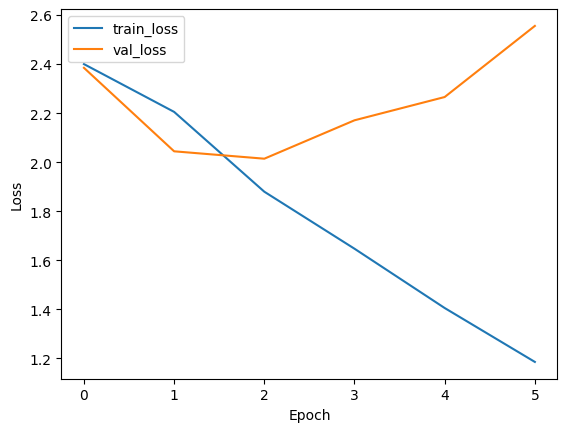

I0000 00:00:1779784373.826442 3422236 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9616__.23
I0000 00:00:1779784374.273919 3424874 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779784374.315839 3424865 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 40 bytes spill stores, 40 bytes spill loads

I0000 00:00:1779784374.767957 3424875 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_17', 8 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779784375.066700 3424876 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779784375.665153 3424867 subprocess_compilation.cc:348] ptxas

17/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1998 - loss: 2.0429

I0000 00:00:1779784377.981477 3422235 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9616__.23


27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.1940 - loss: 2.0717

Test Loss: 2.0716943740844727
Test Accuracy: 0.19401197135448456


In [38]:
# График лосса на трейне и валидации
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Оценка модели на тестовой выборке
test_loss, test_accuracy = transformer_model.evaluate(X_test, y_test)
print(f'\nTest Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

In [49]:
def tokenize_texts(texts: pd.Series, tokenizer: AutoTokenizer, max_len: int):
    """
    Токенизирует серию текстов и возвращает numpy-массивы.

    Параметры:
    texts : pd.Series
        Тексты, которые нужно перевести в token id.
    tokenizer : AutoTokenizer
        Токенизатор Hugging Face.
    max_len : int
        Фиксированная длина последовательности. Все тексты будут обрезаны или дополнены до нее.

    Возвращает:
    Dict[str, np.ndarray]
        Словарь с ключами input_ids и attention_mask.
    """
    return tokenizer(texts, max_length=max_len, padding="max_length", truncation=True, return_tensors="np", add_special_tokens=True)

In [54]:
# Пример нового отзыва
new_review = "Этот фильм был просто потрясающим! Актеры играли великолепно, и сюжет был захватывающим."

encodings = tokenize_texts(new_review, tokenizer, MAX_LEN)
padded_sequence = encodings["input_ids"]
padded_sequence

array([[    2, 11451,  5880,   991,  9922, 38292, 10837,     5, 52927,
          700, 36125, 58593,    16,   320, 26318,   991, 31813, 69870,
           18,     3,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
      

In [55]:
# Предсказание оценки фильма
prediction = transformer_model.predict(padded_sequence)
predicted_class = np.argmax(prediction, axis=1)

print(f'Predicted Rating: {predicted_class[0]}')

I0000 00:00:1779784567.043944 3422235 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11432__.16
I0000 00:00:1779784568.108290 3425431 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_15', 4 bytes spill stores, 4 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Rating: 9


# негативный отзыв на 50 слов

In [56]:
new_review = """
Фильм оказался полным разочарованием. Сюжет был предсказуемым и скучным, а актерская игра оставляла желать лучшего.
Спецэффекты выглядели дешево, а диалоги были неестественными и натянутыми.
Время, потраченное на просмотр, можно было бы использовать с большей пользой.
Не рекомендую тратить на этот фильм ни времени, ни денег.
"""

encodings = tokenize_texts(new_review, tokenizer, MAX_LEN)
padded_sequence = encodings["input_ids"]
padded_sequence

array([[    2, 18013, 19285, 36130, 57518,   656,    18, 42636,   991,
        50772, 33044,   320, 31791,  8789,    16,   312, 46114,  6769,
         9186, 69489,   603, 55719, 36782,    18, 56231, 35353,   700,
        55466, 70706,    16,   312, 65622,  1610, 73501,  3092,   320,
        69588,  6378,    18, 24121,    16, 43981, 42844,   548, 46247,
           16,  5081,  1563,  6796, 14525,   329, 22291, 74084,    18,
         6226, 53389, 37470,   548,  5557,  5880,  5548,  4204,    16,
         5548, 28486,    18,     3,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
      

In [57]:
# transformer_model
prediction = transformer_model.predict(padded_sequence)
predicted_class = np.argmax(prediction, axis=1)
print(f'transformer_model: {predicted_class[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
transformer_model: 1


# позитивный отзыв на 100 слов

In [58]:
new_review = """
Этот фильм превзошел все мои ожидания! Сюжет был захватывающим и непредсказуемым, а актерская игра просто потрясающей.
Каждый персонаж был проработан до мельчайших деталей, что делало их живыми и реалистичными.
Визуальные эффекты были на высоте, создавая атмосферу, которая полностью погружала в происходящее.
Музыкальное сопровождение идеально дополняло каждую сцену, усиливая эмоциональное воздействие.
Фильм оставил глубокое впечатление и заставил задуматься о важных жизненных вопросах.
Определенно рекомендую к просмотру всем, кто ценит качественное кино!
"""

encodings = tokenize_texts(new_review, tokenizer, MAX_LEN)
padded_sequence = encodings["input_ids"]
padded_sequence

array([[    2, 11451,  5880, 47483, 13495,  2749, 30282, 34379,     5,
        42636,   991, 31813, 69870,   320, 46298, 33044,    16,   312,
        46114,  6769,  9186,  9922, 38292, 10208,    18, 30503, 24018,
          991, 65944,   745, 33674, 73370, 36113,    16,  1046, 64798,
         1870, 53290,   320, 41177, 23263,    18, 71913,  6967, 42620,
         1610,   548, 19063,    16, 42486, 35981,    16,  4146,  9297,
        34301, 18802,   314, 40383,    18, 80294, 47086, 37385, 29649,
        67254, 33517, 36545,    16, 29908,  7385, 67946, 34031,    18,
        18013, 25015, 50996, 33048,   320, 32686, 43258,   326, 33186,
        51460, 38746,    18, 39835, 46742, 53389,   322, 46247,   644,
        15827,    16, 11352, 64796, 52088,  8604,     5,     3,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
      

In [59]:
# transformer_model
prediction = transformer_model.predict(padded_sequence)
predicted_class = np.argmax(prediction, axis=1)
print(f'transformer_model: {predicted_class[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
transformer_model: 9


# нейтральный отзыв на 75 слов

In [60]:
new_review = """
Фильм оказался довольно средним. Сюжет был интересным, но не вызвал сильного эмоционального отклика.
Актерская игра была на уровне, но не выделялась чем-то особенным.
Визуальные эффекты и съемка были качественными, но не впечатляли.
Музыкальное сопровождение подходило к сценам, но не запоминалось.
В целом, фильм можно посмотреть один раз, но он вряд ли оставит глубокое впечатление.
Подходит для непритязательного вечера, но не стоит ожидать чего-то выдающегося.
"""

encodings = tokenize_texts(new_review, tokenizer, MAX_LEN)
padded_sequence = encodings["input_ids"]
padded_sequence

array([[    2, 18013, 19285, 16459, 50174,    18, 42636,   991, 44051,
           16,  1363,   769, 36118, 38577, 64134, 71927,    18, 52927,
         1815,  9186,  1480,   548, 16424,    16,  1363,   769, 30901,
         5856,  5151,    17,  1619, 69987,    18, 71913,  6967, 42620,
          320, 31811,   872,  1610, 65859,   613,    16,  1363,   769,
        30395, 15303,    18, 80294, 47086, 57023,   721,   322, 22651,
          656,    16,  1363,   769, 39596,  5836,    18,   282, 15155,
           16,  5880,  5081, 31050,  2762,  4495,    16,  1363,  1218,
        32264, 10632, 55470, 50996, 33048,    18,  7210, 11568,   871,
        70401, 10272,  2702, 11991, 33643,    16,  1363,   769, 22219,
        36262,  6645,    17,  1619, 67149,    18,     3,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
      

In [61]:
# transformer_model
prediction = transformer_model.predict(padded_sequence)
predicted_class = np.argmax(prediction, axis=1)
print(f'transformer_model: {predicted_class[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
transformer_model: 7
